In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

In [3]:
import torchaudio
import torchaudio.transforms as T
import torch
import torch.nn.functional as F
import os
import random
import numpy as np

# MFCC Config
mfcc_config = {
    "sample_rate": 16000,
    "n_mfcc": 40,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 64
}

# Define MFCC transform
mfcc_transform = T.MFCC(
    sample_rate=mfcc_config["sample_rate"],
    n_mfcc=mfcc_config["n_mfcc"],
    melkwargs={
        "n_fft": mfcc_config["n_fft"],
        "hop_length": mfcc_config["hop_length"],
        "n_mels": mfcc_config["n_mels"]
    }
)

# Data augmentation transforms
class AudioAugmentation:
    def __init__(self, sample_rate=16000):
        self.sample_rate = sample_rate
        self.time_stretch = T.TimeStretch()
        # Initialize with default n_steps, will be modified during augmentation
        self.pitch_shift = T.PitchShift(sample_rate=sample_rate, n_steps=0)
        self.noise_transform = T.Vol(gain=0.1)
        
    def __call__(self, waveform):
        # Randomly apply augmentations
        if random.random() < 0.5:
            waveform = self.time_stretch(waveform, random.uniform(0.8, 1.2))
        if random.random() < 0.5:
            # Create new PitchShift instance with random n_steps
            n_steps = random.uniform(-2, 2)
            pitch_shift = T.PitchShift(sample_rate=self.sample_rate, n_steps=n_steps)
            waveform = pitch_shift(waveform)
        if random.random() < 0.3:
            waveform = self.noise_transform(waveform)
        return waveform

# Path to download the dataset
data_path = './data'

# Define a subclass to access train/valid/test split if needed
class SubsetSC(torchaudio.datasets.SPEECHCOMMANDS):
    def __init__(self, subset: str = None):
        super().__init__(data_path, download=True)

        def load_list(filename):
            filepath = os.path.join(self._path, filename)
            with open(filepath) as f:
                return [os.path.join(self._path, line.strip()) for line in f]

        if subset == "validation":
            self._walker = load_list("validation_list.txt")
        elif subset == "testing":
            self._walker = load_list("testing_list.txt")
        elif subset == "training":
            excludes = load_list("validation_list.txt") + load_list("testing_list.txt")
            excludes = set(excludes)
            self._walker = [w for w in self._walker if w not in excludes]

# Custom wrapper that applies MFCC, pads/truncates, and supports .targets
class MFCCSpeechCommands(torch.utils.data.Dataset):
    def __init__(self, subset: str = "training", transform=None, label_to_index=None, max_len: int = 100, augment: bool = False):
        self.dataset = SubsetSC(subset)
        self.transform = transform
        self.max_len = max_len
        self.augment = augment and subset == "training"
        self.audio_augment = AudioAugmentation() if self.augment else None

        # Build consistent label mapping
        if label_to_index is None:
            all_labels = sorted(set(label for _, _, label, *_ in self.dataset))
            self.label_to_index = {label: i for i, label in enumerate(all_labels)}
        else:
            self.label_to_index = label_to_index

        self.targets = [self.label_to_index[label] for _, _, label, *_ in self.dataset]

    def __getitem__(self, index):
        waveform, sample_rate, label, *_ = self.dataset[index]
        
        # Apply audio augmentation if training
        if self.augment:
            waveform = self.audio_augment(waveform)
            
        # Apply MFCC transform
        features = self.transform(waveform) if self.transform else waveform  # shape: [1, 40, T]
        
        # Normalize features
        features = (features - features.mean()) / (features.std() + 1e-8)

        # Pad or truncate to fixed time length
        if features.shape[-1] < self.max_len:
            pad_amount = self.max_len - features.shape[-1]
            features = F.pad(features, (0, pad_amount))
        elif features.shape[-1] > self.max_len:
            features = features[..., :self.max_len]

        return features, self.label_to_index[label]

    def __len__(self):
        return len(self.dataset)

# Create label-to-index mapping once
base_dataset = SubsetSC("training")
unique_labels = sorted(set(label for _, _, label, *_ in base_dataset))
label_to_index = {label: i for i, label in enumerate(unique_labels)}

# Wrap datasets with MFCC transform and shared label mapping
trainset = MFCCSpeechCommands("training", transform=mfcc_transform, label_to_index=label_to_index, augment=True)
val_set  = MFCCSpeechCommands("validation", transform=mfcc_transform, label_to_index=label_to_index)
testset  = MFCCSpeechCommands("testing", transform=mfcc_transform, label_to_index=label_to_index)

print(f"Train samples:     {len(trainset)}")
print(f"Validation samples:{len(val_set)}")
print(f"Test samples:      {len(testset)}")
print(f"Number of classes: {len(label_to_index)}")

Train samples:     105829
Validation samples:9981
Test samples:      11005
Number of classes: 35


In [4]:
num_clients = 5
partitions = {
    "iid":   dirichlet_partition(trainset, num_clients=num_clients, alpha=1000),
}


=== Partition Statistics for SC ===

IID Partition:
Total samples: 105829

Per-client distribution:
Client 0: 21105 samples (19.94%)
Client 1: 21313 samples (20.14%)
Client 2: 21197 samples (20.03%)
Client 3: 20944 samples (19.79%)
Client 4: 21270 samples (20.10%)
[Debug] Number of classes: 35
[Debug] Number of clients: 5
[Debug] Processing client 0 with 21105 samples
[Debug] Client 0 has 21105 valid targets
[Debug] Client 0 class counts: [314. 384. 420. 393. 437. 795. 751. 802. 324. 308. 744. 817. 421. 441.
 308. 731. 422. 750. 774. 720. 770. 783. 733. 811. 410. 804. 782. 753.
 356. 771. 749. 311. 423. 809. 784.]
[Debug] Processing client 1 with 21313 samples
[Debug] Client 1 has 21313 valid targets
[Debug] Client 1 class counts: [347. 412. 411. 407. 421. 810. 760. 807. 300. 308. 745. 774. 401. 415.
 316. 757. 404. 778. 826. 799. 795. 780. 775. 807. 414. 724. 808. 716.
 355. 767. 751. 330. 432. 853. 808.]
[Debug] Processing client 2 with 21197 samples
[Debug] Client 2 has 21197 valid

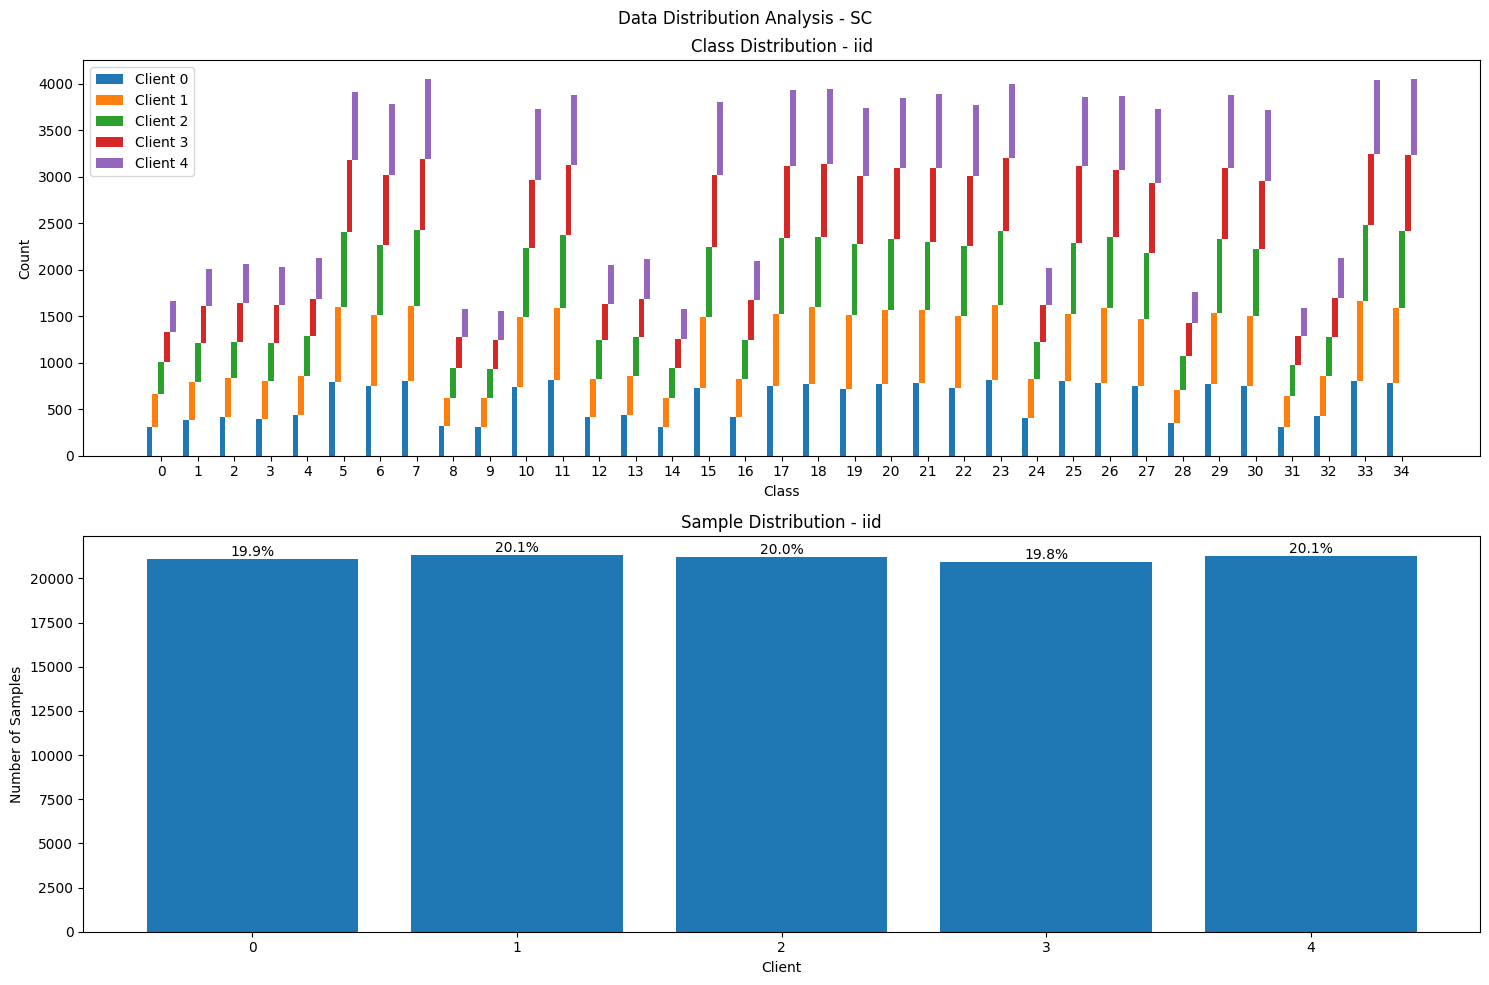

In [5]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "SC")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "SC")
plt.show()

In [6]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("speechcommands")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x0000021117419850>
optimizer: {'type': 'sgd', 'lr': 0.001, 'weight_decay': 0.0001}
lr_scheduler: {'type': 'cosine', 'T_max': 50, 'eta_min': 1e-05, 'warmup_epochs': 3, 'warmup_start_lr': 1e-05}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
quantization: {'bits': 8, 'enabled': True, 'adaptive': True, 'min_bits': 4, 'max_bits': 16, 'layer_specific': True, 'error_threshold': 0.01, 'momentum': 0.9}
mfcc_config: {'sample_rate': 16000, 'n_mfcc': 40, 'n_fft': 1024, 'hop_length': 512}

TinyProp Parameters:
S_min: 0.5
S_max: 0.95
zeta: 0.5
number_of_layers: 6


In [ ]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Get base config
    config = get_tinyprop_config('speechcommands')
    
    # Run training
    model, metrics = federated_training(
        client_datasets=client_datasets,
        model_name='speechcommands',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/speechcommands_metrics.csv',  # Single CSV file for all partitions
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        save_dir='results',
        save_interval=1,
        use_dense_baseline=False
    )
    
    # Print summary statistics
    print(f"\nTraining Summary for {partition_name.upper()}:")
    print(f"Final Accuracy: {metrics['accuracy'][-1]:.4f}")
    print(f"Average Sparsity: {np.mean(metrics['sparsity']):.4f}")
    print(f"Average Compression Ratio: {np.mean(metrics['compression_ratio']):.4f}")
    print(f"Average Effective Compute Ratio: {np.mean(metrics['effective_compute_ratio']):.4f}")
    print(f"Total Communication Cost: {metrics['communication'][-1]/1024:.2f} KB")
    print(f"Total Memory Saved: {metrics['memory_saved'][-1]:.2f} MB")
    
    return model, metrics

# Run training for each partition
partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, metrics = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'metrics': metrics
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue


Starting training for IID partition...

Training on partition: IID

[Training Debug] Initializing clients...
[Training Debug] Client 0 initialized with 21105 samples
[Training Debug] Client 1 initialized with 21313 samples
[Training Debug] Client 2 initialized with 21197 samples
[Training Debug] Client 3 initialized with 20944 samples
[Training Debug] Client 4 initialized with 21270 samples

Round 1/100
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 0

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000


C:\Users\la7tim\AppData\Local\Temp\ipykernel_35096\4060774516.py:41: UserWarning: The input to TimeStretch must be complex type. Providing non-complex tensor produces invalid results.
  waveform = self.time_stretch(waveform, random.uniform(0.8, 1.2))


[Training Debug][Client 0] Error during training: Sizes of tensors must match except in dimension 2. Expected size 1 but got size 201 for tensor number 1 in the list.

[Training Debug] Training client 1

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000
[Training Debug][Client 1] Error during training: Sizes of tensors must match except in dimension 2. Expected size 1 but got size 201 for tensor number 1 in the list.

[Training Debug] Training client 2

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000
[Training Debug][Client 2] Error during training: Sizes of tensors must match except in dimension 2. Expected size 1 but got size 201 for tensor number 1 in the list.

[Training Debug] Training client 3

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000
[Training Debug][Client 3] Error during training: Sizes of tensors must matc